## 5. Evaluation

Walk-forward comparison on the shared horizon-1-to-8 grid, against seasonal-naive and the
RBA's own published forecasts. Aligning each forecast origin to the RBA's actual published Statement on Monetary Policy figures is prepared in [Appendix §14 — RBA Forecast Error Benchmark Preparation](appendix_eda/14_rba_forecast_benchmark).

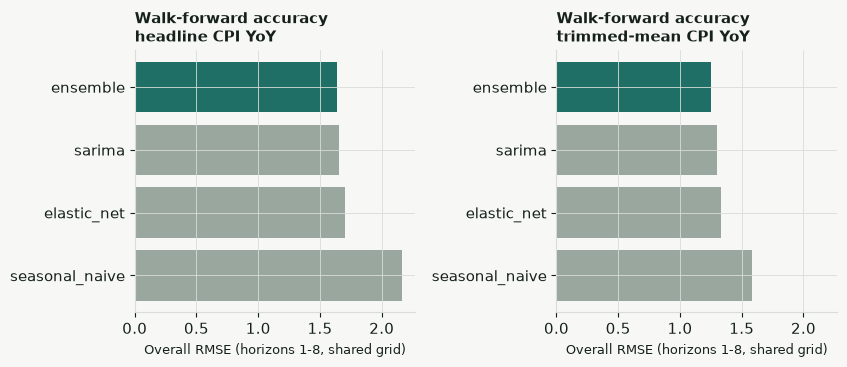

,target,model,n,rmse,mae
0,Headline,ensemble,424,1.640356,1.159850
1,Headline,sarima,424,1.652592,1.155351
2,Headline,elastic_net,424,1.705798,1.245831
3,Headline,seasonal_naive,424,2.163358,1.518632
4,Trimmed mean,ensemble,424,1.249152,0.802744
5,Trimmed mean,sarima,424,1.298886,0.776841
6,Trimmed mean,elastic_net,424,1.333597,0.915858
7,Trimmed mean,seasonal_naive,424,1.580535,0.926179


In [2]:
comp = pd.read_csv(PROJECT_ROOT / "reports/tableau/model_comparison.csv")
panels = [("Headline", "headline CPI YoY"), ("Trimmed mean", "trimmed-mean CPI YoY")]

fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.8), sharex=True)
for ax, (target, title) in zip(axes, panels):
    overall = comp[comp["target"] == target].sort_values("rmse")
    colors = [ACCENT if model == "ensemble" else "#9aa79f" for model in overall["model"]]
    ax.barh(overall["model"], overall["rmse"], color=colors)
    ax.invert_yaxis()
    ax.set_xlabel("Overall RMSE (horizons 1-8, shared grid)", fontsize=9)
    ax.set_title(f"Walk-forward accuracy\n{title}", loc="left", fontsize=11, fontweight="bold")
fig.tight_layout()
plt.show()
comp.sort_values(["target", "rmse"])[["target", "model", "n", "rmse", "mae"]].reset_index(drop=True)

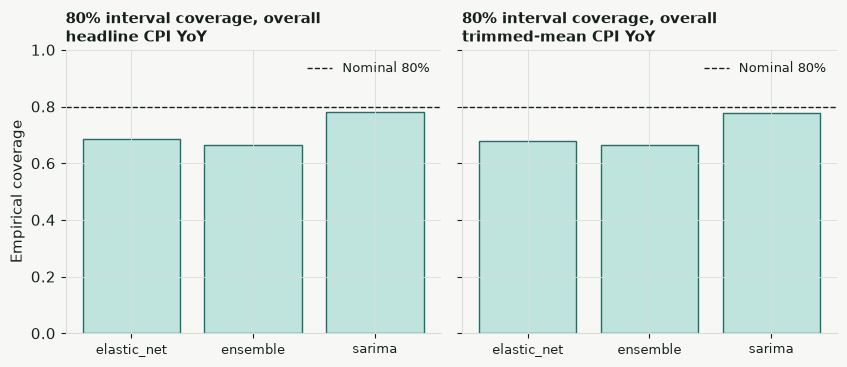

In [3]:
cov = pd.read_csv(PROJECT_ROOT / "reports/tableau/model_interval_coverage.csv")

fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.8), sharey=True)
for ax, (target, title) in zip(axes, panels):
    cov_overall = cov[cov["target"] == target].sort_values("model")
    ax.axhline(cov_overall["nominal_coverage"].iloc[0], color=INK, linestyle="--",
               linewidth=1, label="Nominal 80%")
    ax.bar(cov_overall["model"], cov_overall["empirical_coverage"], color=ACCENT_SOFT, edgecolor=ACCENT)
    ax.set_ylim(0, 1)
    ax.set_title(f"80% interval coverage, overall\n{title}", loc="left", fontsize=11, fontweight="bold")
    ax.tick_params(axis="x", labelsize=9)
    ax.legend(frameon=False, fontsize=9)
axes[0].set_ylabel("Empirical coverage")
fig.tight_layout()
plt.show()

Across both targets, Elastic Net and the Ensemble still fall short of their nominal 80% interval
coverage (`reports/tableau/model_interval_coverage.csv`); SARIMA now sits close to it and is no
longer flagged as significantly miscalibrated. SARIMA covers 78.1% for headline and 77.8% for
trimmed mean. Elastic Net covers 68.4% and 67.9%, respectively; the Ensemble covers 66.5% and 66.3%.

These intervals are calibrated with an ex-ante rolling scale factor: each forecast origin is widened
using only the forecast errors already observed by that quarter (pooled over the last 12 quarters),
scored on the side of the interval the outcome landed on. Coverage is much weaker on the 2020–23
origins, where errors jumped several-fold; there, held-out calibrated coverage is 56–72% for trimmed
mean and 55–62% for headline, at roughly twice the interval width. No interval built from past errors
can anticipate a shock of that size, so this narrows the gap without closing it. See
`reports/model_interval_calibration_remediation_decisions.md`.

The Ensemble has the lowest point-forecast RMSE on both targets: 1.640 for headline and
1.249 for trimmed mean, compared with SARIMA's 1.653 and 1.299. These modest point-forecast
gains do not resolve the interval-coverage gap. Seasonal naive is a point-forecast benchmark
and has no interval-coverage row in these exports.